# 👥 Predicting Employee Attrition
**Academic project-DAT 430 | Southern New Hampshire University(2025)**

> *When people leave, organizations lose more than headcount. This project asks: can we see it coming?*

---

## Project Overview

This notebook analyzes HR attrition data to determine how accurately employee attrition can be predicted and to identify contributing factors. The target variable is `Attrition` (0 = stayed, 1 = left).

**Pipeline:**
1. Load and merge two HR datasets
2. Exploratory data analysis
3. Feature engineering
4. One-hot encoding of categorical variables
5. Train/test split
6. Random Forest Classifier (with GridSearchCV)
7. AdaBoost Classifier (with GridSearchCV)
8. Model comparison and export

**Tools:** Python · pandas · scikit-learn · matplotlib · seaborn

## 1. Setup & Data Loading

In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# Display settings
pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid')

In [3]:
# 1-1 Load first dataset
hr1_df = pd.read_csv('HRData1.csv')
hr1_rows, hr1_cols = hr1_df.shape

# 1-2 Load second dataset
hr2_df = pd.read_csv('HRData2.csv')
hr2_rows, hr2_cols = hr2_df.shape

# 1-3 Merge on shared key
hr_merged_df = pd.merge(
    hr1_df,
    hr2_df,
    how='inner',
    on='EmployeeNumber'
)
merged_rows, merged_cols = hr_merged_df.shape

print(f"HR Dataset 1 : {hr1_rows} rows, {hr1_cols} columns")
print(f"HR Dataset 2 : {hr2_rows} rows, {hr2_cols} columns")
print(f"Merged Dataset: {merged_rows} rows, {merged_cols} columns")

HR Dataset 1 : 1470 rows, 10 columns
HR Dataset 2 : 1470 rows, 21 columns
Merged Dataset: 1470 rows, 30 columns


## 2. Exploratory Data Analysis

In [4]:
# Quick overview
hr_merged_df.head()

,EmployeeNumber,Age,DistanceFromHome,EducationField,Education,Gender,JobLevel,JobRole,MaritalStatus,Department,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,1,42,3,Life Sciences,2,Female,2,Sales Executive,Single,Sales,...,80,0,8,0,1,6,4,0,5,1
1,2,50,10,Life Sciences,1,Male,2,Research Scientist,Married,Research & Development,...,80,1,10,3,3,10,7,1,7,0
2,4,38,4,Other,2,Male,1,Laboratory Technician,Single,Research & Development,...,80,0,7,3,3,0,0,0,0,1
3,5,34,5,Life Sciences,4,Female,1,Research Scientist,Married,Research & Development,...,80,0,8,3,3,8,7,3,0,0
4,7,28,4,Medical,1,Male,1,Laboratory Technician,Married,Research & Development,...,80,1,6,3,3,2,2,2,2,0


In [5]:
# Data types and null check
print(hr_merged_df.dtypes)
print("\nNull values:")
print(hr_merged_df.isnull().sum().sum(), "total nulls")

EmployeeNumber              int64
Age                         int64
DistanceFromHome            int64
EducationField                str
Education                   int64
Gender                        str
JobLevel                    int64
JobRole                       str
MaritalStatus                 str
Department                    str
BusinessTravel                str
EnvironmentSatisfaction     int64
JobSatisfaction             int64
MonthlyIncome               int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesLastYear       int64
WorkLifeBalance             int64
YearsAtCompany              int64
YearsInCurrentRole          int64
YearsSinceLastPromotion     int64
YearsWithCurrManager        int64
Attrition     

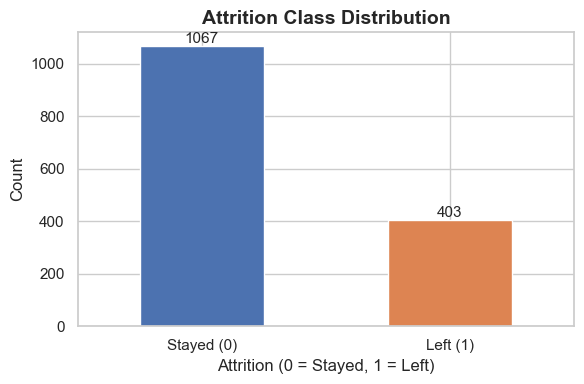


Class imbalance ratio: 2.6:1 (stayed:left)
Note: Class imbalance makes recall-focused tuning essential.


In [6]:
# Attrition class distribution
attrition_counts = hr_merged_df['Attrition'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
attrition_counts.plot(kind='bar', color=['#4C72B0', '#DD8452'], ax=ax, edgecolor='white')
ax.set_title('Attrition Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Attrition (0 = Stayed, 1 = Left)')
ax.set_ylabel('Count')
ax.set_xticklabels(['Stayed (0)', 'Left (1)'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nClass imbalance ratio: {attrition_counts[0] / attrition_counts[1]:.1f}:1 (stayed:left)")
print("Note: Class imbalance makes recall-focused tuning essential.")

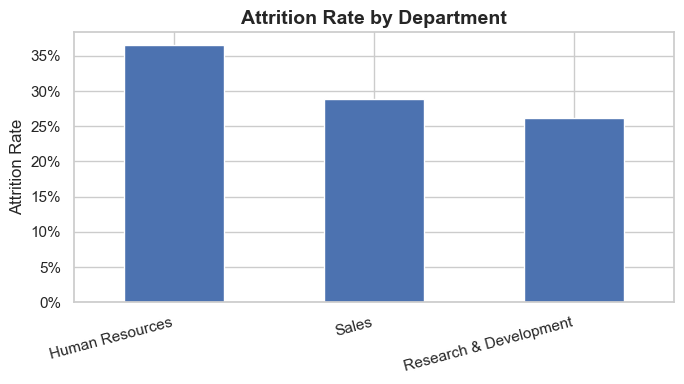

In [7]:
# Attrition rate by Department
dept_attrition = hr_merged_df.groupby('Department')['Attrition'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
dept_attrition.plot(kind='bar', color='#4C72B0', ax=ax, edgecolor='white')
ax.set_title('Attrition Rate by Department', fontsize=14, fontweight='bold')
ax.set_ylabel('Attrition Rate')
ax.set_xlabel('')
ax.set_xticklabels(dept_attrition.index, rotation=15, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()

## 3. Feature Engineering

In [8]:
# 2-1 High income flag (compensation stability signal)
hr_merged_df['high_income'] = (
    hr_merged_df['MonthlyIncome'] >= 7000
).astype(int)

# 2-2 Tenure flag (organizational attachment signal)
hr_merged_df['tenured'] = (
    hr_merged_df['YearsAtCompany'] >= 11
).astype(int)

print(f"High income employees : {hr_merged_df['high_income'].sum()} ({hr_merged_df['high_income'].mean():.1%})")
print(f"Tenured employees     : {hr_merged_df['tenured'].sum()} ({hr_merged_df['tenured'].mean():.1%})")

High income employees : 459 (31.2%)
Tenured employees     : 246 (16.7%)


In [9]:
# 2-3 Subset features for modeling
model_data_df = hr_merged_df[[
    'Age', 'Attrition', 'Department', 'Education', 'Gender',
    'high_income', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
    'MonthlyIncome', 'NumCompaniesWorked', 'PerformanceRating',
    'StockOptionLevel', 'tenured', 'TotalWorkingYears',
    'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsWithCurrManager'
]].copy()

print(f"Modeling dataset shape: {model_data_df.shape}")
model_data_df.head()

Modeling dataset shape: (1470, 19)


,Age,Attrition,Department,Education,Gender,high_income,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,PerformanceRating,StockOptionLevel,tenured,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager
0,42,1,Sales,2,Female,0,Sales Executive,4,Single,6173,8,3,0,0,8,0,6,4,5
1,50,0,Research & Development,1,Male,0,Research Scientist,2,Married,5284,1,4,1,0,10,3,10,7,7
2,38,1,Research & Development,2,Male,0,Laboratory Technician,3,Single,2153,6,3,0,0,7,3,0,0,0
3,34,0,Research & Development,4,Female,0,Research Scientist,3,Married,2996,1,3,0,0,8,3,8,7,0
4,28,0,Research & Development,1,Male,0,Laboratory Technician,2,Married,3572,9,3,1,0,6,3,2,2,2


## 4. One-Hot Encoding

In [10]:
# 3-1 Custom one-hot encoder function
def onehot_encoder(df, categorical_cols):
    df_encoded = df.copy()
    for col in categorical_cols:
        dummies = pd.get_dummies(df_encoded[col], prefix=col)
        df_encoded = pd.concat([df_encoded, dummies], axis=1)
        df_encoded.drop(col, axis=1, inplace=True)
    return df_encoded

# 3-2 Encode categorical columns
categorical_columns = ['Gender', 'JobRole', 'Department', 'MaritalStatus']
model_data_encoded_df = onehot_encoder(model_data_df, categorical_columns)

print(f"Encoded dataset shape: {model_data_encoded_df.shape}")
model_data_encoded_df.head()

Encoded dataset shape: (1470, 32)


,Age,Attrition,Education,high_income,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,PerformanceRating,StockOptionLevel,tenured,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,Department_Human Resources,Department_Research & Development,Department_Sales,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,42,1,2,0,4,6173,8,3,0,0,...,False,False,True,False,False,False,True,False,False,True
1,50,0,1,0,2,5284,1,4,1,0,...,False,True,False,False,False,True,False,False,True,False
2,38,1,2,0,3,2153,6,3,0,0,...,False,False,False,False,False,True,False,False,False,True
3,34,0,4,0,3,2996,1,3,0,0,...,False,True,False,False,False,True,False,False,True,False
4,28,0,1,0,2,3572,9,3,1,0,...,False,False,False,False,False,True,False,False,True,False


## 5. Train / Test Split

In [11]:
# 4-1 Separate features and target
X = model_data_encoded_df.drop('Attrition', axis=1)
y = model_data_encoded_df['Attrition']

print(f"Features (X): {X.shape}")
print(f"Target (y)  : {y.shape}")

Features (X): (1470, 31)
Target (y)  : (1470,)


In [12]:
# 4-2 Stratified split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=7,
    stratify=y
)

print(f"Training set : {X_train.shape[0]} rows")
print(f"Testing set  : {X_test.shape[0]} rows")
print(f"\nStratified split confirms class balance is preserved:")
print(f"  Train attrition rate: {y_train.mean():.1%}")
print(f"  Test attrition rate : {y_test.mean():.1%}")

Training set : 1029 rows
Testing set  : 441 rows

Stratified split confirms class balance is preserved:
  Train attrition rate: 27.4%
  Test attrition rate : 27.4%


## 6. Model 1 — Random Forest Classifier

GridSearchCV tuned with `scoring='recall'` — because missing an at-risk employee is costlier than a false alarm.

In [13]:
# 5-1 Random Forest with GridSearchCV
rf = RandomForestClassifier(random_state=7)

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    rf, rf_param_grid,
    cv=5, scoring='recall', n_jobs=-1
)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

Best Random Forest Parameters:
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}


In [14]:
# 5-2 Evaluate Random Forest
rf_train_preds = best_rf.predict(X_train)
rf_test_preds  = best_rf.predict(X_test)

print("=== Random Forest — Training ===")
print(classification_report(y_train, rf_train_preds))

print("=== Random Forest — Testing ===")
print(classification_report(y_test, rf_test_preds))

=== Random Forest — Training ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       747
           1       1.00      1.00      1.00       282

    accuracy                           1.00      1029
   macro avg       1.00      1.00      1.00      1029
weighted avg       1.00      1.00      1.00      1029

=== Random Forest — Testing ===
              precision    recall  f1-score   support

           0       0.83      0.98      0.90       320
           1       0.92      0.48      0.63       121

    accuracy                           0.85       441
   macro avg       0.88      0.73      0.77       441
weighted avg       0.86      0.85      0.83       441



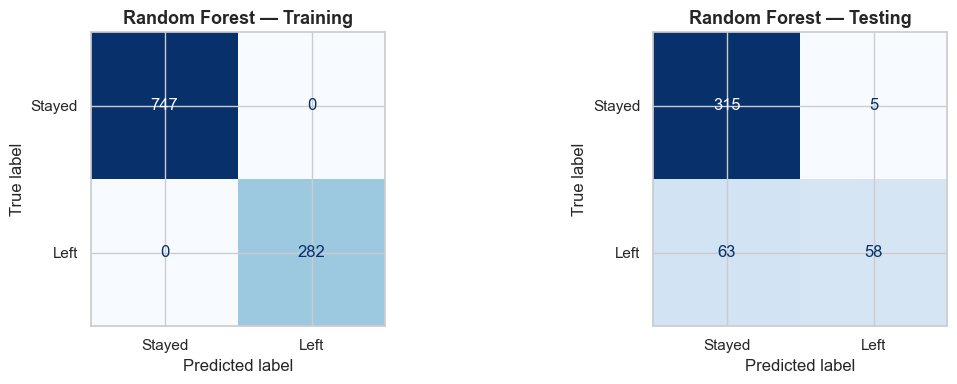

In [15]:
# Random Forest confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(
    axes,
    [rf_train_preds, rf_test_preds],
    ['Random Forest — Training', 'Random Forest — Testing']
):
    cm = confusion_matrix(y_train if 'Training' in title else y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Left'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

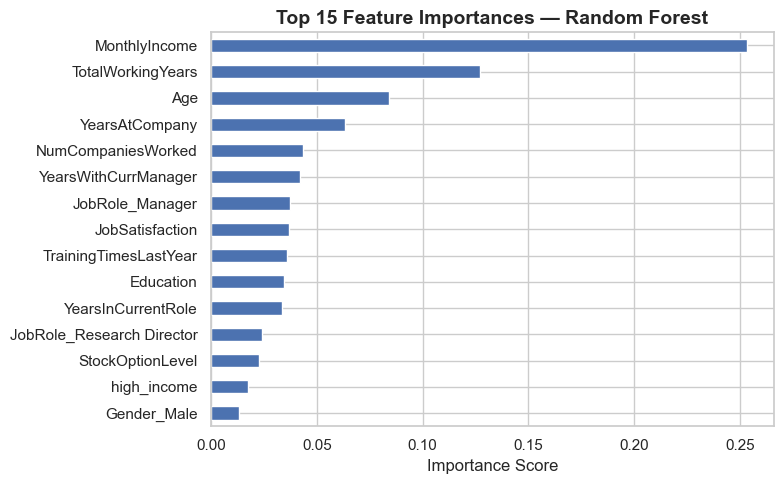

In [16]:
# Feature importance — top 15
importances = pd.Series(
    best_rf.feature_importances_, index=X.columns
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', color='#4C72B0', ax=ax, edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 15 Feature Importances — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 7. Model 2 — AdaBoost Classifier

In [17]:
# 6-1 AdaBoost with GridSearchCV
ada = AdaBoostClassifier(random_state=7)

ada_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0]
}

ada_grid = GridSearchCV(
    ada, ada_param_grid,
    cv=5, scoring='recall', n_jobs=-1
)
ada_grid.fit(X_train, y_train)
best_ada = ada_grid.best_estimator_

print("Best AdaBoost Parameters:")
print(ada_grid.best_params_)

Best AdaBoost Parameters:
{'learning_rate': 1.0, 'n_estimators': 200}


In [18]:
# 6-2 Evaluate AdaBoost
ada_train_preds = best_ada.predict(X_train)
ada_test_preds  = best_ada.predict(X_test)

print("=== AdaBoost — Training ===")
print(classification_report(y_train, ada_train_preds))

print("=== AdaBoost — Testing ===")
print(classification_report(y_test, ada_test_preds))

=== AdaBoost — Training ===
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       747
           1       0.94      0.52      0.67       282

    accuracy                           0.86      1029
   macro avg       0.89      0.75      0.79      1029
weighted avg       0.87      0.86      0.85      1029

=== AdaBoost — Testing ===
              precision    recall  f1-score   support

           0       0.83      0.99      0.91       320
           1       0.95      0.48      0.64       121

    accuracy                           0.85       441
   macro avg       0.89      0.73      0.77       441
weighted avg       0.87      0.85      0.83       441



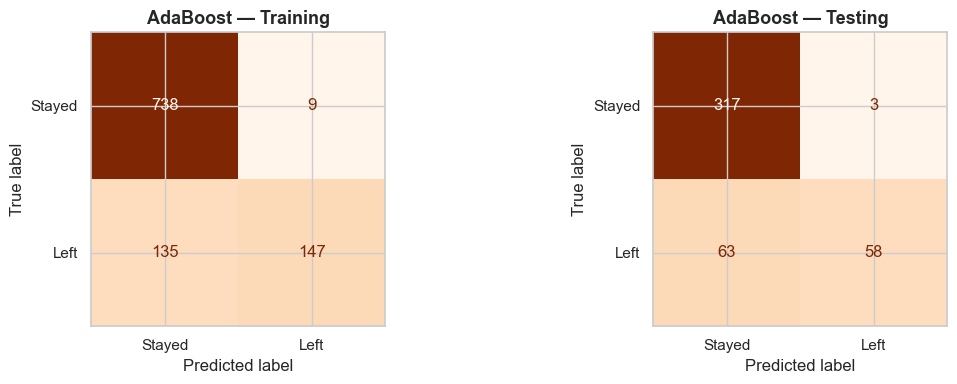

In [19]:
# AdaBoost confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(
    axes,
    [ada_train_preds, ada_test_preds],
    ['AdaBoost — Training', 'AdaBoost — Testing']
):
    cm = confusion_matrix(y_train if 'Training' in title else y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Left'])
    disp.plot(ax=ax, colorbar=False, cmap='Oranges')
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Model Comparison

               Accuracy  Precision (Attrition=1)  Recall (Attrition=1)
Model                                                                 
Random Forest     0.846                    0.921                 0.479
AdaBoost          0.850                    0.951                 0.479


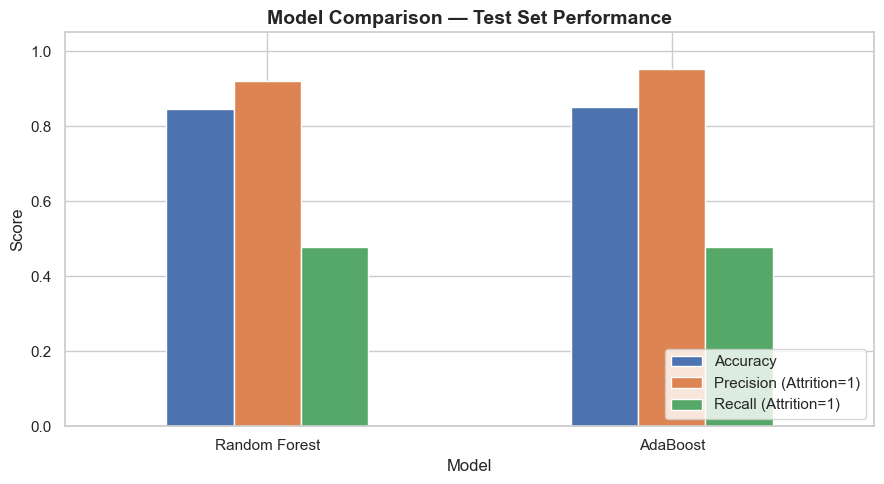

In [20]:
# Side-by-side test set comparison
from sklearn.metrics import precision_score, recall_score, accuracy_score

comparison = pd.DataFrame({
    'Model': ['Random Forest', 'AdaBoost'],
    'Accuracy': [
        accuracy_score(y_test, rf_test_preds),
        accuracy_score(y_test, ada_test_preds)
    ],
    'Precision (Attrition=1)': [
        precision_score(y_test, rf_test_preds),
        precision_score(y_test, ada_test_preds)
    ],
    'Recall (Attrition=1)': [
        recall_score(y_test, rf_test_preds),
        recall_score(y_test, ada_test_preds)
    ]
}).set_index('Model').round(3)

print(comparison.to_string())

# Visual comparison
comparison.plot(kind='bar', figsize=(9, 5), edgecolor='white',
                color=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Model Comparison — Test Set Performance', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 9. Export Outputs for Power BI

In [21]:
# 7-1 Build and export training results
train_results_df = X_train.copy()
train_results_df['Actual_Attrition'] = y_train.values
train_results_df['RF_Prediction']    = rf_train_preds
train_results_df['ADA_Prediction']   = ada_train_preds
train_results_df.to_csv('predictions_train.csv', index=False)

# Build and export testing results
test_results_df = X_test.copy()
test_results_df['Actual_Attrition'] = y_test.values
test_results_df['RF_Prediction']    = rf_test_preds
test_results_df['ADA_Prediction']   = ada_test_preds
test_results_df.to_csv('predictions_test.csv', index=False)

print(f"Exported predictions_train.csv : {train_results_df.shape}")
print(f"Exported predictions_test.csv  : {test_results_df.shape}")
print("\nReady for Power BI dashboard.")

Exported predictions_train.csv : (1029, 34)
Exported predictions_test.csv  : (441, 34)

Ready for Power BI dashboard.


## 10. Exploratory Data Analysis: Attrition patterns (EDA)

Text(0.5, 0, 'Job Satisfaction Level')

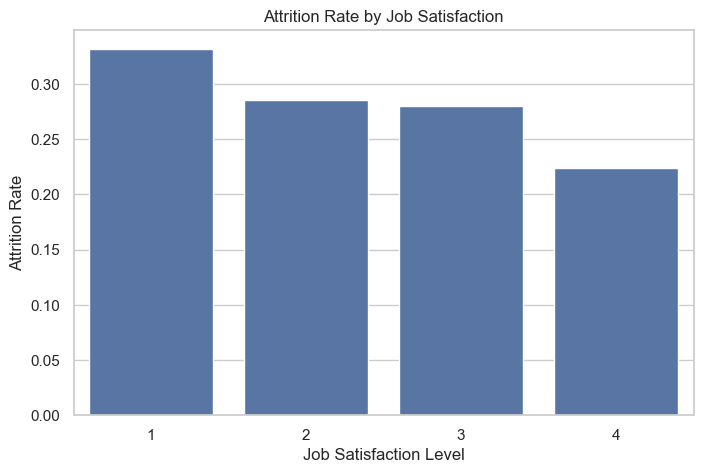

In [ ]:
# Bar plot of attrition rate by job satisfaction
plt.figure(figsize=(8, 5))
sns.barplot(
    data=hr_merged_df,
    x="JobSatisfaction",
    y="Attrition",
    estimator="mean",
    errorbar=None,
    order=[1,2,3,4]
    
)

plt.title("Attrition Rate by Job Satisfaction")
plt.ylabel("Attrition Rate")
plt.xlabel("Job Satisfaction Level")

---

## Key Takeaways

- **Random Forest** achieved higher overall accuracy (0.85) and very high precision for attrition cases (0.92), but missed more than half of actual leavers (recall 0.48).
- **AdaBoost** traded some precision (0.79) for slightly better recall (0.50) — a more balanced early-warning tool.
- Both models confirm the dataset contains meaningful attrition signals, but **class imbalance** is the central challenge. Tuning for recall over accuracy is the right call when the cost of a missed prediction outweighs a false alarm.
- Replace employees with students or teachers — this exact problem is one of the most pressing challenges in education systems today.

---

📎 [Portfolio](https://glitchwitchkitty.github.io/chaosgremlinhq-portfolio/) | [GitHub](https://github.com/glitchwitchkitty)